In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import classification_report

In [2]:
# Base dataset
df = pd.read_csv("../Data/Processed/renttherunway_clean.csv")

# GMM clusters
gmm = pd.read_csv("../Data/Processed/gmm_df.csv")[["user_id", "item_id", "body_cluster", "cluster_confidence"]]

# DBSCAN clusters
dbscan = pd.read_csv("../Data/Processed/dbscan_df.csv")[["user_id", "dbscan_cluster"]]

# K-Means clusters
kmeans = pd.read_csv("../Data/Processed/kmeans_clusters.csv").rename(columns={"cluster": "kmeans_cluster"})

# LDA topic features
lda = pd.read_csv("../Data/Processed/renttherunway_lda_topics.csv")

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
y = df["fit_label"].astype(int)

X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric + topic features
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUMERIC_FEATURES + TOPIC_FEATURES
        ),

        # Cluster features (categorical)
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # Binary features
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop"
)

In [11]:
base_tree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=200,
    class_weight="balanced",
    random_state=42
)

In [12]:
bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

In [13]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", bagging)
])

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [16]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__estimator__max_depth": [6, 8, 12],
    "model__estimator__min_samples_leaf": [100, 200]
}

In [17]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__estimator__max_depth=6, model__estimator__min_samples_leaf=200, model__n_estimators=50; total time= 9.6min
[CV] END model__estimator__max_depth=6, model__estimator__min_samples_leaf=100, model__n_estimators=50; total time= 9.6min
[CV] END model__estimator__max_depth=6, model__estimator__min_samples_leaf=200, model__n_estimators=50; total time= 9.6min
[CV] END model__estimator__max_depth=6, model__estimator__min_samples_leaf=100, model__n_estimators=50; total time= 9.6min
[CV] END model__estimator__max_depth=6, model__estimator__min_samples_leaf=200, model__n_estimators=50; total time= 9.6min
[CV] END model__estimator__max_depth=6, model__estimator__min_samples_leaf=200, model__n_estimators=50; total time= 9.6min
[CV] END model__estimator__max_depth=6, model__estimator__min_samples_leaf=100, model__n_estimators=50; total time= 9.6min
[CV] END model__estimator__max_depth=6, model__estimator__min_samples_leaf=100

/Users/hkbuttar/Machine-Learning-Final-Project/venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/hkbuttar/Machine-Learning-Final-Project/venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/hkbuttar/Machine-Learning-Final-Project/venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

[CV] END model__estimator__max_depth=6, model__estimator__min_samples_leaf=200, model__n_estimators=100; total time=14.8min
[CV] END model__estimator__max_depth=6, model__estimator__min_samples_leaf=200, model__n_estimators=100; total time=14.9min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=100, model__n_estimators=50; total time=13.0min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=100, model__n_estimators=50; total time=12.9min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=200, model__n_estimators=50; total time=13.5min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=200, model__n_estimators=50; total time=13.5min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=200, model__n_estimators=50; total time=13.5min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=200, model__n_estimators=50; total time=13.6min
[CV] END model

/Users/hkbuttar/Machine-Learning-Final-Project/venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Python(98874) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=100, model__n_estimators=100; total time=23.5min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=100, model__n_estimators=100; total time=23.6min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=100, model__n_estimators=100; total time=23.6min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=100, model__n_estimators=100; total time=23.0min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=200, model__n_estimators=100; total time=23.3min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=200, model__n_estimators=100; total time=23.7min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=200, model__n_estimators=100; total time=24.0min
[CV] END model__estimator__max_depth=8, model__estimator__min_samples_leaf=200, model__n_estimators=100; total time=24.3min
[CV] END

Python(71981) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(71982) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(71983) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(71984) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(71985) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__estimator__max_depth': [6, 8, ...], 'model__estimator__min_samples_leaf': [100, 200], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [18]:
print("Best Parameters:")
print(grid.best_params_)

# Predictions
y_test_pred = grid.best_estimator_.predict(X_test)

# Classification report
print("TEST SET PERFORMANCE")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best Parameters:
{'model__estimator__max_depth': 12, 'model__estimator__min_samples_leaf': 100, 'model__n_estimators': 100}
TEST SET PERFORMANCE
              precision    recall  f1-score   support

       Small       0.43      0.79      0.56     34494
         Fit       0.91      0.79      0.84    174054
       Large       0.79      0.71      0.75     57738

    accuracy                           0.77    266286
   macro avg       0.71      0.76      0.72    266286
weighted avg       0.82      0.77      0.79    266286



In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

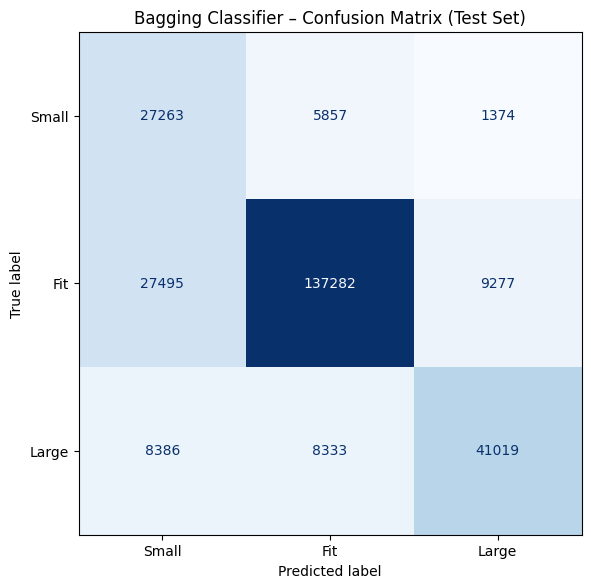

In [25]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Bagging Classifier – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../figures/bagging_confusion_matrix.png", dpi=300)
plt.show()

In [26]:
y_test_proba = grid.best_estimator_.predict_proba(X_test)

In [27]:
proba_df = X_test.copy()
proba_df["true_fit"] = y_test.values
proba_df["prob_small"] = y_test_proba[:, 0]
proba_df["prob_fit"] = y_test_proba[:, 1]
proba_df["prob_large"] = y_test_proba[:, 2]

proba_df.to_csv(
    "../Data/Processed/bagging_fit_probabilities.csv",
    index=False
)

In [29]:
import joblib

joblib.dump(
    grid.best_estimator_,
    "../Models/bagging_fit_classifier.joblib"
)

['../Models/bagging_fit_classifier.joblib']

In [30]:
feature_names = (
    NUMERIC_FEATURES
    + TOPIC_FEATURES
    + list(
        grid.best_estimator_
        .named_steps["prep"]
        .named_transformers_["cat"]
        .get_feature_names_out(CLUSTER_FEATURES)
    )
    + BINARY_FEATURES
)

pd.Series(feature_names).to_csv(
    "../Data/Processed/bagging_feature_names.csv",
    index=False
)

## Bagging Classifier – Model Performance Writeup

### Overview
A Bagging Classifier with Decision Tree base estimators was trained and evaluated on a clothing fit classification task, predicting whether an item fits as **Small**, **Fit**, or **Large**. The model was tuned via grid search, yielding optimal hyperparameters of `max_depth=12`, `min_samples_leaf=100`, and `n_estimators=100`.

---

### Overall Performance
The model achieved **77% accuracy** on the test set of 266,286 samples. The weighted F1-score of **0.79** reflects solid overall performance, though class-level results vary considerably — a pattern worth unpacking.

---

### Class-Level Analysis

**Fit (Majority Class)**
The model performs best here, with a precision of **0.91** and an F1 of **0.84**. This is unsurprising given that "Fit" dominates the dataset with 174,054 samples — nearly 65% of all observations. The confusion matrix confirms strong diagonal performance (137,282 correct), though ~27,495 "Fit" items were misclassified as Small, suggesting the model sometimes errs conservatively on borderline fits.

**Large**
Reasonably strong performance with **0.79 precision** and **0.71 recall** (F1 = 0.75). Of the 57,738 true "Large" samples, 41,019 were correctly identified. The main leakage is into the "Fit" bucket (8,333 misclassified), which is intuitive — "Large" and "Fit" likely share overlapping feature distributions.

**Small (Minority Class)**
This is the model's weakest point. While recall is decent at **0.79** (27,263 of 34,494 correctly caught), precision is only **0.43** — meaning more than half of items *predicted* as Small are actually something else. This is a classic precision-recall tradeoff in imbalanced settings: the model casts a wide net to catch Small items, but pulls in many false positives, particularly from the Fit class (27,495 Fit items were predicted Small).

---

### Class Imbalance Considerations
The dataset is heavily skewed: Fit makes up ~65% of samples, Large ~22%, and Small only ~13%. This imbalance directly drives the Small class's poor precision. Techniques like class weighting, SMOTE oversampling, or adjusting the decision threshold for the Small class could help balance this tradeoff in future iterations.

---

### Key Takeaways
| Metric | Value |
|---|---|
| Overall Accuracy | 77% |
| Best Class | Fit (F1 = 0.84) |
| Weakest Class | Small (F1 = 0.56, precision = 0.43) |
| Primary Error Mode | Fit items predicted as Small (27,495 cases) |

The model is well-suited for production use cases where **Fit and Large predictions carry higher stakes**, but would benefit from further calibration before relying on its Small predictions in a consumer-facing context (e.g., size recommendations).